# Electromagnetism Homework #2
### Due: Friday, February 6, 2026 at 5:00PM
Problems marked with [*] are potential sources for quiz questions.

## Problem 1: Do the following (1-4)
1.  Find the conduction electron number density, $n$, in a piece of copper, assuming each atom contributes one free electron. (Look up the necessary physical constants.)

-------------------------------------------------------------------------------------
2. Calculate the average electron velocity, ie the drift velocity, in a copper wire 1-mm in diameter, carrying a current of 1 A.

-------------------------------------------------------------------------------------
3. For copper, at room temperature the electrons form a degenerate Fermi gas with rms speed of $vrms ≈ 1.22 × 106 m/s$. This is the speed at which the free electrons are whizzing around randomly inside the copper. The drift velocity is superimposed on top of this random motion and is many, many, orders of magnitude smaller.

-------------------------------------------------------------------------------------
4. Write a simple computer code to convince yourself that a small but steady drift velocity will emerge when averaging a large number of random thermal velocities with the drift velocity superimposed.

Hint: Do not use the real thermal velocity or drift velocity. Pick something like a drift “speed” of 0.01 and a thermal “speed” chosen randomly from the range (−1,1).
If using Python, take a look at numpy’s random library: https://numpy.org/doc/stable/reference/random/index.html.

Warning: The smaller you make the drift speed, the more averages you need to take before the drift becomes apparent. This is expected behavior and reflects the physics of the problem. Very large numbers of averages may take a long time to run or cause memory issues

## Problem 1 Solution: Conceptual (1-3)

### 1. 
For the conduction electron number density you must know the molar mass of the piece of copper, the number of free electrons per atom, and the mass per unit volume of the copper. The number of conduction atoms is assumed to be 1. After looking up the mass per unit volume of copper, I found it to be 8960 kg per cubic meter or 8.96 grams per cubic centimeter. We must also use avogadros number in this equation which will be down below. The final piece is knowing the molar mass of the piece of copper. Putting all of this together we get the equation: $$n = \frac{(\rho * Z) * (6.022 * 10^{23} mol^{-1})}{M}$$ 
Plugging all these in results in $8.49 * 10^{28} electrons/m^3$

-------------------------------------------------------------------------------------
### 2. 
So I thought this last equation was wrong and I was about to use the equation from the notes, but I found out it is correct. What I didn't realize was that the n in the equation from day 1 notes is what im looking for in question 1. 

Anyways now that we have our answer for question 1 we can find our drift velocity from the equation: $$i = nAv_{drift}$$
Rearranging: $$v_{drift} = \frac{i}{nA}$$
Just so its in here, i is the current, n is the conduction electron number density, and A is the cross section area of the wire. Lets go ahead and write down the area $A = \pi r^{2} = \pi (0.0005m)^{2} = 7.85 * 10^{-7} m^{2}$. 

Now we can solve our equation for the drift velocity: $$v_{drift} = \frac{1}{(8.49 * 10^{28})(7.85 * 10^{-7})}$$
This gives us a drift velocity of: $1.5 * 10^{-23}$ m/s

This does not seem right. And I was right about that. What we are missing is the basic charge of one electron which is $1.602 * 10^{-19}$ C. Throwing that into the denominator gives us: $$v_{drift} = \frac{1}{(8.49 * 10^{28})(1.602 * 10^{-19})(7.85 * 10^{-7})}$$
This then comes out to: $v_{drift} = 9.4 * 10^{-5}$ m/s. This looks right as its very slow but not as slow as our other answer. Reading the notes I know that the drift velocity is supposed to be slow. Usually less than a millimeter a second. 

-------------------------------------------------------------------------------------
### 3. 
The answer to problem 2 fits this statement. 

### Problem 1 Solution: Coding (4)

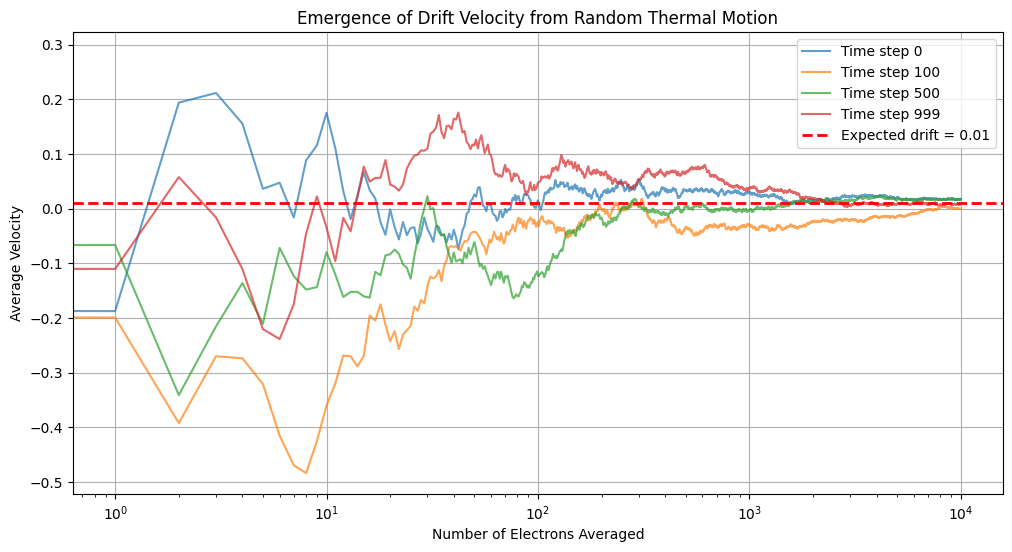

Expected drift velocity: 0.01
Measured average velocity: 0.009953
Percent error: 0.47%


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
drift_speed = 0.01  # Small drift velocity
n_electrons = 10000  # Number of electrons to simulate
n_samples = 1000     # Number of time steps

# Generate random thermal velocities in range (-1, 1)
thermal_velocities = np.random.uniform(-1, 1, (n_samples, n_electrons))

# Add drift velocity to thermal motion
total_velocities = thermal_velocities + drift_speed

# Calculate cumulative average velocity over increasing numbers of electrons
cumulative_avg = np.cumsum(total_velocities, axis=1) / np.arange(1, n_electrons + 1)

# Plot results for several time snapshots
plt.figure(figsize=(12, 6))

# Plot cumulative average for a few time steps
for i in [0, 100, 500, 999]:
    plt.plot(cumulative_avg[i, :], label=f'Time step {i}', alpha=0.7)

plt.axhline(y=drift_speed, color='r', linestyle='--', linewidth=2, label=f'Expected drift = {drift_speed}')
plt.xlabel('Number of Electrons Averaged')
plt.ylabel('Average Velocity')
plt.title('Emergence of Drift Velocity from Random Thermal Motion')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.show()

# Print final average
final_avg = np.mean(total_velocities)
print(f"Expected drift velocity: {drift_speed}")
print(f"Measured average velocity: {final_avg:.6f}")
print(f"Percent error: {abs(final_avg - drift_speed)/drift_speed * 100:.2f}%")

## Problem 2: 
A battery of emf $\epsilon$ and internal resistance r is hooked up to a variable "load" resistance, R, as illustrated below. 

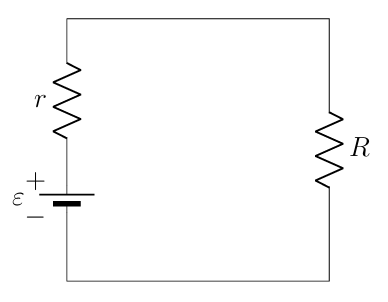

-------------------------------------------------------------------------------------
1. Show that an expression for the power $P_{L}(R)$ delivered to the load resistor in terms of the battery emf $(\epsilon)$, the battery internal resistance (r), and the load resistance (R) is: $$P_{L}(R) = \frac{\epsilon^{2}R}{(R+r)^{2}}$$

-------------------------------------------------------------------------------------
2. The efficiency, η, is the ratio of the energy (or power) doing what we want divided by the total energy (or power) it takes to do it. Assume the battery is 100% efficient in converting chemical energy into electrical energy. Show that the efficiency of this circuit is given by: $$\eta(R) = \frac{R}{R+r}$$

-------------------------------------------------------------------------------------
3.  Find the load resistance that maximizes the power delivered to the load. (You can’t change ε and r, of course.) Determine the efficiency at this max power load resistance. What do you think about that efficiency? (good, bad, meh?) What does that value of load resistance imply about the energy dissipated in the battery?

-------------------------------------------------------------------------------------
4.  A typical new 12-V car battery has an emf of 12-V and an internal resistance of 5-mΩ (yes, milli-ohms). Make plots of PL(R) and η(R) for R in the range 0.1mΩ < R < 1Ω. Clearly highlight the value of r in the plot(s). Hint: use logarithmic scaling on the x-axis. You can also put both plots on one graph - just make them distinctive.

-------------------------------------------------------------------------------------
5. A typical starter motor draws several hundred amps from the battery and has an effective winding resistance on the order of 10–30 mΩ, which is larger than the battery’s internal resistance (∼ 10 times larger). Using your plots and calculations, explain why the starter motor winding resistance is not designed to equal the battery’s internal resistance, even though that would maximize power transfer.

### Problem 2 Solution: 

### 1. 

-------------------------------------------------------------------------------------
### 2. 

-------------------------------------------------------------------------------------
### 3. 

-------------------------------------------------------------------------------------
### 4. 

-------------------------------------------------------------------------------------
### 5. 



### Problem 3 [*] 
A metal bar of mass m slides frictionlessly on two parallel conducting rails a distance ℓ apart as shown below. A resistor R is connected across the rails and a uniform magnetic field B, pointing into the page, fills the same region.

-------------------------------------------------------------------------------------
1. If the bar moves to the right at speed v, what is the current in the resistor? In what direction does it flow?

-------------------------------------------------------------------------------------
2. What is the magnetic force on the bar? What direction?

-------------------------------------------------------------------------------------
3. If the bar starts out with speed v0 at time t = 0, and is left to slide, what is its speed at a later time t?

-------------------------------------------------------------------------------------
4. The initial kinetic energy of the bar was, of course, $\frac{1}{2}mv_{0}^{2}$. Check that the energy delivered to the resistor is exactly $\frac{1}{2}mv_{0}^{2}$.

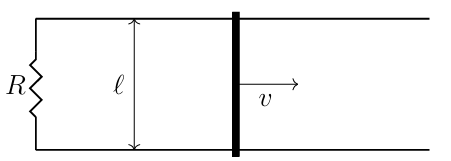

### Problem 3 Solution: 

### 1. 

-------------------------------------------------------------------------------------
### 2. 

-------------------------------------------------------------------------------------
### 3. 

-------------------------------------------------------------------------------------
### 4. 

### Problem 4: 
An ideal inductor, illustrated below, used in circuit theory is often physically realized as a solenoid. In this problem, we will first derive the inductance of a solenoid from Maxwell’s equations and then apply the result to the design of an AM radio tuning circuit.

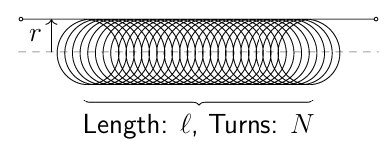


1. Consider a long solenoid of length ℓ, cross-sectional area A, and N tightly wound turns carrying a steady current I. Using Ampère’s Law, determine the magnetic field B inside the solenoid. Clearly state any assumptions used.

-------------------------------------------------------------------------------------
2. Calculate the magnetic flux through a single turn of the solenoid and hence determine the total flux linkage λ. Using the definition λ = LI, obtain an expression for the inductance L of the solenoid in terms of N, A, and ℓ.

-------------------------------------------------------------------------------------
3. The magnetic energy density is given by: $$u = \frac{B^{2}}{2\mu_{0}}$$
Compute the total magnetic energy stored in the solenoid and use it to rederive the inductance found in part (b). Comment briefly on the agreement between the two methods.

-------------------------------------------------------------------------------------
4. A simple AM radio receiver uses an LC circuit to select stations in the AM broadcast band, which spans frequencies from: $$f_{min} = 530kHz \space\space to \space\space f_{max} = 1700kHz$$
A typical AM variabe capacitor has a tuning range from: $$C_{max} = 365pF \space\space to \space\space C_{min} = 35pF$$

4 (i) ----> Assuming the circuit resonates at fmin when C = Cmax, determine the inductance L required for tuning. Recall the resonace frequency for a LC circuit is ω = 2πf = 1/√LC.

4 (ii) -----> Using this inductance, calculate the resonance frequency when C = Cmin. Is the full AM band covered?

-------------------------------------------------------------------------------------
5. The inductor is constructed by winding wire around a cylindrical ferrite rod with diameter $$D = 1.0cm$$
and winding length $$l = 10cm$$
Model the inductor as a solenoid with inductance $$L = \mu_{0}\mu_{eff}\frac{N^{2}A}{l},$$
where $\mu_{eff}$ is the effective relative permeability of the core.

5 (i): Calculate the number of turns required to achieve the inductance found in part (4), assuming $\mu_{eff} = 20$.

5 (ii): Repeat the calculation for an air-core inductor ($\mu_{eff} = 1$). By what factor does the required number of turns change?

-------------------------------------------------------------------------------------
6. Typical AM ferrite-rod inductors use on the order of 102 turns of wire. Is your result consistent with this expectation?

### Problem 4 Solution: 

### 1. 

-------------------------------------------------------------------------------------
### 2. 

-------------------------------------------------------------------------------------
### 3. 

-------------------------------------------------------------------------------------
### 4. 

-------------------------------------------------------------------------------------
### 5. 

-------------------------------------------------------------------------------------
### 6. 

### Problem 5 [*]: THE BIG ONE
In this problem we consider electrical power generation with a simple toy model illustrated below. A uniform magnetic field points in the $\hat{z}$ direction while a circular coil of wire rotates about its diameter with angular speed, $\omega$.
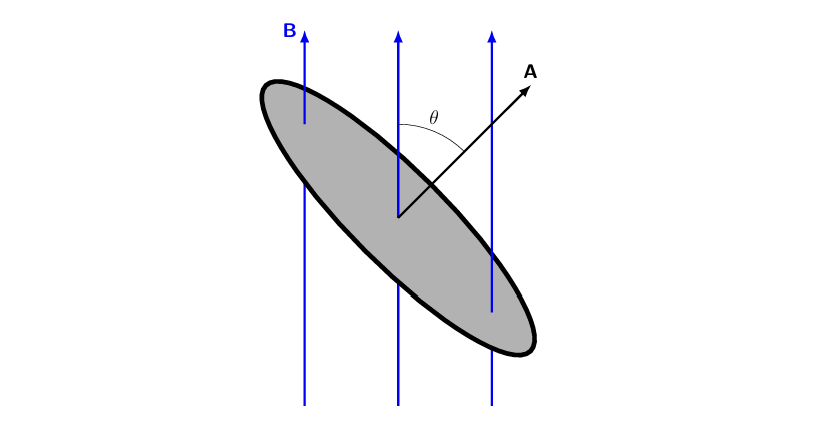
1. Compute the magnetic flux, $\Phi_{m}(t)$, for this system.

-------------------------------------------------------------------------------------
2. Compute the induced emf in the coil, ε(t).

-------------------------------------------------------------------------------------
3. Consider the coil having resistance in its windings, Rw, and inductance, L, and being in series with a load resistance, RL, as illustrated below. Use Kirchoff’s loop rule to write down an equation for the voltages around the loop for this circuit:
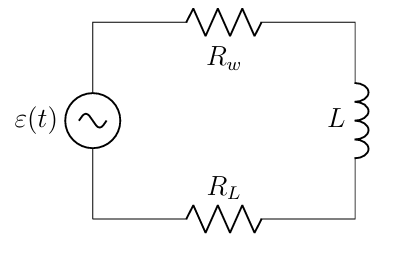

You should find: $$L\frac{dI}{dt} + R_{tot}I = \epsilon\sin{(\omega t)},$$

-------------------------------------------------------------------------------------
4. Integrate the ODE from the previous part to determine the steady state current in the coil, I(t). You should find: $$I(t) = \frac{\epsilon_{0}\sin{(\omega t - \phi)}}{\sqrt{R_{tot}^{2} + (\omega L_{w})^{2}}} = I_{0}\sin{(\omega t - \phi)},$$
where $\epsilon_{0} = NBA\omega$, $R_{tot} = R_{w} + R_{L}$, and $\phi = \tan^{-1}(\frac{\omega L}{R})$. Hint: We are assuming the coil has been rotating for a “long time” and are not intereted in the transient solution.

-------------------------------------------------------------------------------------
5. Do the following:

(i) What is the phase angle, φ, if ωL ≪ Rtot?

(ii) What is the phase angle if ωL ∼ Rtot

(iii) What is the phase angle if ωL ≫ Rtot?

These values span this simple generator's two regimes (resistance dominated and inductance dominated). 

-------------------------------------------------------------------------------------
6. Treat the flat, circular, coil as N turns of wire and compute it’s magnetic dipole moment, µ. Refer to Chapter 5, Equation 5.86.

-------------------------------------------------------------------------------------
7. Compute the torque on the coil in the B-field, $$\tau = \mu \times B$$
You should find the magnitude of the torque to be, $$\tau(t) = \frac{NAB I_{0}}{2} [\cos{\phi} - \cos{(2\omega t - \phi)}]$$

-------------------------------------------------------------------------------------
8. Compute an expression for the time-averaged torque, ⟨τ⟩, then evaluate it for our two regimes (resistance dominated and inductance dominated).

-------------------------------------------------------------------------------------
9. Recall from your physics class that the infinitesimal work done by a torque is, $dW = \tau d\theta$, such that the mechanical power is, $P_{mech}(t) = \tau(t)\omega$, where $\omega = \frac{d\theta}{dt}$ from the beginning of the problem. Compute the average mechanical power, $P_{mech}$. Then compute the electrical power delivered to $R_{tot}$, its average, and show that $P_{elec}$ equals $P_{mech}$. What does this mean?

-------------------------------------------------------------------------------------
10.  Assume the following numerical values: B = 0.5T, the coil has an area of $0.01 m^{2}$ and is composed of $N = 200$ turns of wire. The total resistance is $R_{tot} = 10$ Ohms and the frequency of rotation is 60Hz. Given the frequency and resistance compute effective inductance values for the ratios: $\frac{\omega L_{eff}}{R_{tot}} = [0.1, 1, 10]$. 

-------------------------------------------------------------------------------------
11. Make the following plots over several periods of oscillation:

11 (i): 
$\epsilon (t)$

11 (ii): 
I(t) for the three $\frac{\omega L_{eff}}{R_{tot}}$ cases. Put them all on one plot and make them distinctive. Comment on the plot (ie how is the phase angle showing up for each case).

11 (iii):
$\tau (t)$ for the three $\frac{\omega L_{eff}}{R_{tot}}$ cases.Put them all on one plot and make them distinctive. Comment on the plot (ie how is the phase angle showing up and what is $\tau$ for each case).

11 (iv):
$P_{mech}$ for the three $\frac{\omega L_{eff}}{R_{tot}}$ cases.Put them all on one plot and make them distinctive. Comment on the plot (ie how is the phase angle showing up and what is $P_{mech}$ for each case).

11 (v):
$P_{elec}$ for the three $\frac{\omega L_{eff}}{R_{tot}}$ cases.Put them all on one plot and make them distinctive. Comment on the plot (ie how is the phase angle showing up and what is $P_{elec}$ for each case). 


### Problem 5 Solution: (1 - 10)

### 1. 

-------------------------------------------------------------------------------------
### 2. 

-------------------------------------------------------------------------------------
### 3. 

-------------------------------------------------------------------------------------
### 4. 

-------------------------------------------------------------------------------------
### 5. 

-------------------------------------------------------------------------------------
### 6. 

-------------------------------------------------------------------------------------
### 7. 

-------------------------------------------------------------------------------------
### 8. 

-------------------------------------------------------------------------------------
### 9. 

-------------------------------------------------------------------------------------
### 10. 

### Problem 5 Solution: CODING (11)

In [ ]:
# plots for epsilon(t)



In [ ]:
# Plots for I(t)



In [ ]:
#plots for tau(t)



In [ ]:
# Plots for P_mech(t)



In [ ]:
# Plots for P_elec(t)

